# Smart Quality Monitoring & Analytics System

This project visualizes manufacturing quality metrics through a Tableau dashboard powered by a dual-mode data pipeline. Users can operate in manual mode (CSV import) or automatic mode (Python-generated data).

### Import necessary libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading CSV file

In [8]:
df_manufacturing = pd.read_csv('manufacturing-quality-control-dataset.csv')
df_manufacturing

,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01T15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02T09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04T00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03T16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04T08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,T8452-20240624,2024-06-24,PRD-04,morning,OP-2186,INSP-0046,2024-06-24T08:55:00,INS-2517,97.5,NaN,NaN,0,False,No defects found during inspection.,Factory-Y7
196,U3917-20240624,2024-06-24,PRD-01,afternoon,OP-7777,INSP-0047,2024-06-24T15:23:00,INS-0112,76.9,dent,2.0,1,False,"Minor dent found, batch passes.",Factory-X0
197,V8093-20240625,2024-06-25,PRD-03,night,OP-1674,INSP-0048,2024-06-26T00:03:00,INS-3452,47.5,contamination,3.0,6,True,Batch failed due to contamination.,Factory-G9
198,W5076-20240625,2024-06-25,PRD-02,afternoon,OP-5691,INSP-0049,2024-06-25T14:57:00,INS-5648,98.2,NaN,NaN,0,False,Batch PRD-02 meets all benchmarks.,Factory-E1


ensure dates are parsed and create useful columns like date, hour, shift

In [7]:

df = df_manufacturing.copy()

# parse date columns if present
for c in ['production_date', 'inspection_date']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

# create safe columns for time-based grouping
if 'production_date' in df.columns:
    df['prod_date'] = df['production_date'].dt.date
    df['prod_hour'] = df['production_date'].dt.hour
    df['prod_weekday'] = df['production_date'].dt.day_name()
    
# quick view
print("Rows,Cols:", df.shape)
display(df.head())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False).head(20))


Rows,Cols: (200, 18)


,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location,prod_date,prod_hour,prod_weekday
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01 15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1,2024-06-01,0,Saturday
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02 09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7,2024-06-02,0,Sunday
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04 00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3,2024-06-03,0,Monday
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03 16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0,2024-06-03,0,Monday
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04 08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9,2024-06-04,0,Tuesday



Missing values per column:
 defect_type         89
defect_severity     89
production_date      0
prod_hour            0
prod_date            0
factory_location     0
comments             0
rework_required      0
defect_count         0
batch_id             0
quality_score        0
inspector_id         0
inspection_date      0
inspection_id        0
operator_id          0
shift                0
product_code         0
prod_weekday         0
dtype: int64


In [11]:
df.isnull().sum()   

batch_id             0
production_date      0
product_code         0
shift                0
operator_id          0
inspection_id        0
inspection_date      0
inspector_id         0
quality_score        0
defect_type         89
defect_severity     89
defect_count         0
rework_required      0
comments             0
factory_location     0
prod_date            0
prod_hour            0
prod_weekday         0
dtype: int64

### Data Cleaning and preprocessing 

In [12]:
df

,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location,prod_date,prod_hour,prod_weekday
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01 15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1,2024-06-01,0,Saturday
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02 09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7,2024-06-02,0,Sunday
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04 00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3,2024-06-03,0,Monday
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03 16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0,2024-06-03,0,Monday
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04 08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9,2024-06-04,0,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,T8452-20240624,2024-06-24,PRD-04,morning,OP-2186,INSP-0046,2024-06-24 08:55:00,INS-2517,97.5,NaN,NaN,0,False,No defects found during inspection.,Factory-Y7,2024-06-24,0,Monday
196,U3917-20240624,2024-06-24,PRD-01,afternoon,OP-7777,INSP-0047,2024-06-24 15:23:00,INS-0112,76.9,dent,2.0,1,False,"Minor dent found, batch passes.",Factory-X0,2024-06-24,0,Monday
197,V8093-20240625,2024-06-25,PRD-03,night,OP-1674,INSP-0048,2024-06-26 00:03:00,INS-3452,47.5,contamination,3.0,6,True,Batch failed due to contamination.,Factory-G9,2024-06-25,0,Tuesday
198,W5076-20240625,2024-06-25,PRD-02,afternoon,OP-5691,INSP-0049,2024-06-25 14:57:00,INS-5648,98.2,NaN,NaN,0,False,Batch PRD-02 meets all benchmarks.,Factory-E1,2024-06-25,0,Tuesday


In [14]:
df.isnull().sum()

batch_id             0
production_date      0
product_code         0
shift                0
operator_id          0
inspection_id        0
inspection_date      0
inspector_id         0
quality_score        0
defect_type         89
defect_severity     89
defect_count         0
rework_required      0
comments             0
factory_location     0
prod_date            0
prod_hour            0
prod_weekday         0
dtype: int64

In [15]:
df.describe()

,production_date,inspection_date,quality_score,defect_severity,defect_count,prod_hour
count,200,200,200.000000,111.000000,200.000,200.0
mean,2024-06-05 06:14:24,2024-06-05 22:22:56.749999872,75.699400,2.612613,3.225,0.0
min,2023-02-28 00:00:00,2023-03-01 01:18:49,0.000000,1.000000,0.000,0.0
25%,2024-06-04 00:00:00,2024-06-04 22:05:09,63.600000,2.000000,0.000,0.0
50%,2024-06-07 00:00:00,2024-06-07 10:28:22,81.150000,3.000000,1.000,0.0
75%,2024-06-14 00:00:00,2024-06-14 10:10:38.249999872,96.225000,4.000000,5.000,0.0
max,2024-06-30 00:00:00,2024-07-01 02:37:55,100.000000,4.000000,20.000,0.0
std,NaN,NaN,25.157249,1.113317,5.025,0.0


In [16]:
df.duplicated().sum()

np.int64(0)

### EDA

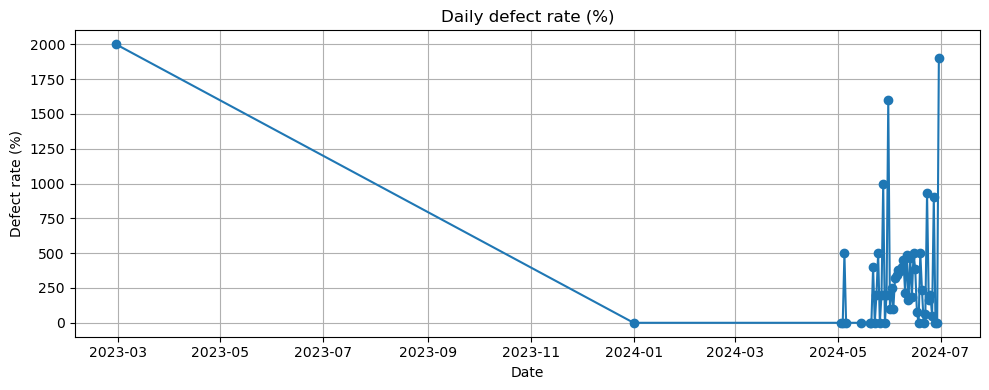

In [17]:
# Aggregate per day
if 'prod_date' in df.columns:
    daily = df.groupby('prod_date').agg(
        total_units = ('batch_id','count'),
        total_defects = ('defect_count','sum') if 'defect_count' in df.columns else ('defect_type','count')
    ).reset_index()
    daily['defect_rate_pct'] = 100 * daily['total_defects'] / daily['total_units']

    # plot defect rate trend
    plt.figure(figsize=(10,4))
    plt.plot(daily['prod_date'], daily['defect_rate_pct'], marker='o')
    plt.title('Daily defect rate (%)')
    plt.xlabel('Date')
    plt.ylabel('Defect rate (%)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No production date column parsed; skip time-series plot.")


### Defect analysis by machine / operator / shift

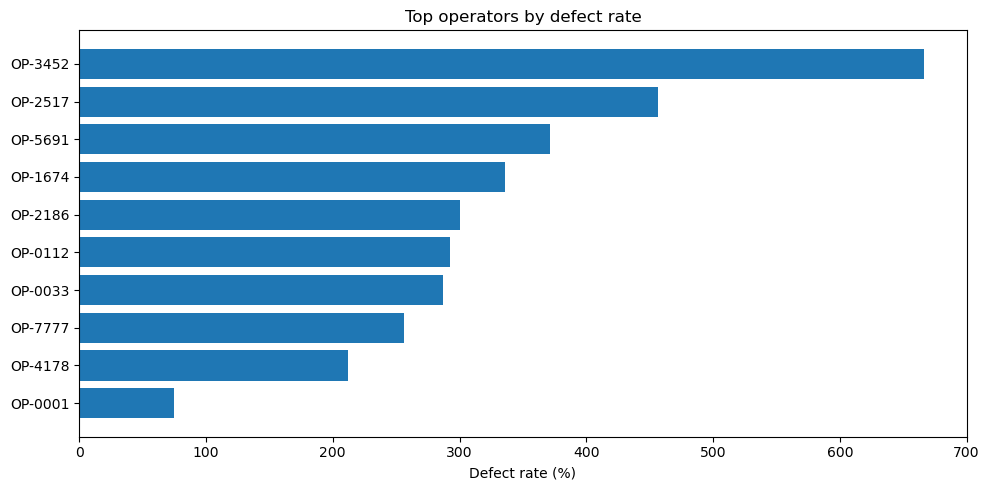

In [18]:
# Example: defects by operator
if 'operator_id' in df.columns:
    by_op = df.groupby('operator_id').agg(total = ('batch_id','count'),
                                          defects = ('defect_count','sum') if 'defect_count' in df.columns else ('defect_type','count'))
    by_op['defect_rate_pct'] = 100 * by_op['defects'] / by_op['total']
    by_op = by_op.sort_values('defect_rate_pct', ascending=False).head(20)
    
    plt.figure(figsize=(10,5))
    plt.barh(by_op.index.astype(str), by_op['defect_rate_pct'])
    plt.gca().invert_yaxis()
    plt.xlabel('Defect rate (%)')
    plt.title('Top operators by defect rate')
    plt.tight_layout()
    plt.show()
else:
    print("No operator_id column.")


### Pareto of defect types (frequency)

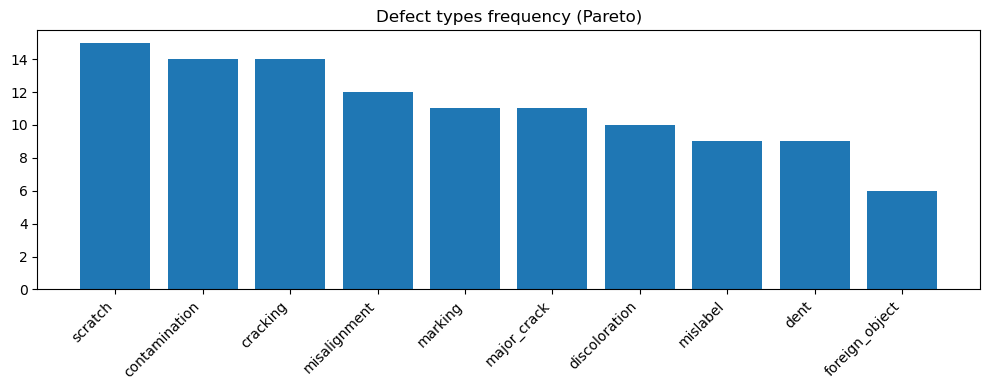

,defect_type,count,cum_pct
0,scratch,15,13.513514
1,contamination,14,26.126126
2,cracking,14,38.738739
3,misalignment,12,49.549550
4,marking,11,59.459459
5,major_crack,11,69.369369
6,discoloration,10,78.378378
7,mislabel,9,86.486486
8,dent,9,94.594595
9,foreign_object,6,100.000000


In [19]:
if 'defect_type' in df.columns:
    counts = df['defect_type'].value_counts().reset_index()
    counts.columns = ['defect_type','count']
    counts['cum_pct'] = 100 * counts['count'].cumsum() / counts['count'].sum()

    plt.figure(figsize=(10,4))
    plt.bar(counts['defect_type'], counts['count'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Defect types frequency (Pareto)')
    plt.tight_layout()
    plt.show()

    display(counts.head(10))   # top 10 defect types
else:
    print("No defect_type column.")
